In [14]:
# PREPARACIÓN E IMPORTACIÓN DE HERRAMIENTAS

import pandas as pd
import numpy as np
import ast # Necesario para convertir los strings de JSON a listas de Python
import os # Necesario para construir la ruta de los archivos en Drive
import matplotlib.pyplot as plt

from sklearn.model_selection import StratifiedShuffleSplit # Para dividir los datos de forma inteligente
from sklearn.preprocessing import StandardScaler, OneHotEncoder # Para escalar y codificar datos
from sklearn.compose import ColumnTransformer # Para aplicar diferentes reglas a diferentes columnas
from sklearn.pipeline import Pipeline # Para encadenar pasos de preprocesamiento y el modelo
from sklearn.linear_model import LinearRegression # Nuestro Modelo 1: simple
from sklearn.ensemble import RandomForestRegressor # Nuestro Modelo 2: más potente
from sklearn.metrics import mean_squared_error, r2_score # Para evaluar qué tan buenos son los modelos
from sklearn.feature_extraction.text import CountVectorizer # Usado para codificar géneros/actores (muchos valores por fila)

# Herramienta para Google Colab:
from google.colab import drive

In [3]:
# CONFIGURACIÓN
try:
    drive.mount('/content/drive')
except Exception:
    # Si no estamos en Colab, esto fallará, pero podemos ignorarlo
    pass

# Definimos la ruta de nuestros archivos CSV y otras constantes
BASE_PATH = "/content/drive/MyDrive/Archivos .csv"
RANDOM_STATE = 42
TARGET = 'bayesian_average' # Nuestro objetivo es predecir esta métrica
MIN_BUDGET = 100000 # Solo queremos películas con presupuesto >= $100,000

Mounted at /content/drive


In [4]:
# FUNCIONES DE AYUDA PARA LIMPIEZA

def safe_literal_eval(value):
    """Convierte el texto JSON/Python a listas o diccionarios reales."""
    if pd.isna(value): return []
    try: return ast.literal_eval(value)
    except (ValueError, SyntaxError, TypeError): return []

def extract_features(data_str, key='name', n=3):
    """Extrae, por ejemplo, los primeros 3 nombres de la lista de actores."""
    items = safe_literal_eval(data_str)
    return [item.get(key) for item in items if item and key in item][:n]

def extract_director(crew_str):
    """Busca al Director dentro de la lista de personas de producción."""
    crew = safe_literal_eval(crew_str)
    for member in crew:
        if member.get('job') == 'Director':
            return member.get('name', 'Unknown')
    return 'Unknown'

def adjust_budget(row, cpi_latest):
    """Ajusta el presupuesto a valores actuales usando el IPC (Inflación)[cite: 21]."""
    if row['budget'] > 0 and not pd.isna(row['CPI']):
        # Fórmula: Presupuesto_Actual = Presupuesto_Original * (CPI_Actual / CPI_Original)
        return row['budget'] * (cpi_latest / row['CPI'])
    return row['budget']

def list_to_string(list_of_items):
    """Convierte una lista a una cadena. ¡Necesario para que CountVectorizer funcione!"""
    if isinstance(list_of_items, list):
        # Unimos los elementos con un espacio. Quitamos espacios internos (ej. "Ciencia Ficción" -> "Ciencia_Ficción")
        return ' '.join(str(item).replace(' ', '_') for item in list_of_items)
    return '' # Si no hay nada, devolvemos una cadena vacía

In [5]:
# CARGA Y EXTRACCIÓN DE DATOS

print("Cargando y fusionando datos...")
try:
    # Cargar los 3 archivos necesarios
    movies = pd.read_csv(os.path.join(BASE_PATH, 'movies_metadata.csv'), low_memory=False)
    credits = pd.read_csv(os.path.join(BASE_PATH, 'credits.csv'))
    cpi_df = pd.read_csv(os.path.join(BASE_PATH, 'CPI.csv'), usecols=['Year', 'Annual Average CPI'])

    # Limpiamos el ID de la película para poder fusionar los archivos [cite: 5, 6]
    movies['id'] = pd.to_numeric(movies['id'], errors='coerce', downcast='integer')
    movies.dropna(subset=['id'], inplace=True)
    movies['id'] = movies['id'].astype(int)

    # ¡Fusionamos todo! Usamos el ID de la película
    data = movies.merge(credits, on='id', how='inner')
    data.drop_duplicates(subset=['id'], inplace=True)
    # Solo nos interesan las películas que tienen votos reales (votantes > 0)
    data = data[data['vote_count'] > 0].copy()

except Exception as e:
    print(f"Error en carga/fusión: ¿Revisaste la ruta '{BASE_PATH}' y los nombres de archivo?")
    raise

Cargando y fusionando datos...


In [6]:
# Convertimos y limpiamos las columnas importantes
data['budget'] = pd.to_numeric(data['budget'], errors='coerce').fillna(0)
data['release_year'] = pd.to_datetime(data['release_date'], errors='coerce').dt.year.fillna(2000).astype(int)

# Extraemos las características obligatorias para el modelo [cite: 24, 25, 26, 27, 28]
data['genres_list'] = data['genres'].apply(lambda x: extract_features(x, key='name', n=5))
data['cast_list'] = data['cast'].apply(lambda x: extract_features(x, key='name', n=3))
data['director'] = data['crew'].apply(extract_director)
data['countries_list'] = data['production_countries'].apply(lambda x: extract_features(x, key='name', n=5))

In [7]:
# APLICACIÓN DE FILTROS

print(f"\nTotal de películas antes del filtrado: {len(data)}")

# FILTRO 1: Presupuesto Mínimo (Presupuesto original)
data = data[data['budget'] >= MIN_BUDGET].copy()
print(f"Películas después de filtrar presupuesto (< ${MIN_BUDGET:,}): {len(data)}")

# FILTRO 2: Solo Películas de Estados Unidos
data = data[data['countries_list'].apply(lambda x: 'United States of America' in x)].copy()
print(f"Películas después de filtrar por producción (Solo USA): {len(data)}")

if data.empty:
    raise ValueError("¡ERROR! El dataset está vacío después de aplicar los filtros. Revisa tus datos.")


Total de películas antes del filtrado: 42534
Películas después de filtrar presupuesto (< $100,000): 8265
Películas después de filtrar por producción (Solo USA): 5979


In [8]:
# AJUSTE DE PRESUPUESTO Y CÁLCULO DEL TARGET

# A. Ajuste del Presupuesto (IPC)
cpi_df.columns = ['Year', 'CPI']
cpi_df.dropna(inplace=True)
cpi_latest = cpi_df['CPI'].max() # Buscamos el CPI del año más reciente

# Hacemos el merge temporal para obtener el IPC de cada película
data = pd.merge(data, cpi_df, left_on='release_year', right_on='Year', how='left')
data['adjusted_budget'] = data.apply(lambda row: adjust_budget(row, cpi_latest), axis=1)
data.drop(columns=['Year', 'CPI', 'countries_list'], inplace=True)

# B. Cálculo de la Media Bayesiana (BA) [cite: 10, 11]
# m: Puntuación media de todo el catálogo [cite: 15]
m = data['vote_average'].mean()
# C: Confianza, usamos la mediana del número de votos [cite: 16, 18]
C = data['vote_count'].median()

# Aplicamos la fórmula: BA = ((v * R) + (C * m)) / (v + C)
data[TARGET] = (data['vote_count'] * data['vote_average'] + C * m) / (data['vote_count'] + C)
data.dropna(subset=[TARGET], inplace=True)

print(f"Películas listas para modelado (con Media Bayesiana calculada): {len(data)}")

Películas listas para modelado (con Media Bayesiana calculada): 5979


In [9]:
# PREPARACIÓN Y SEPARACIÓN

# Convertimos las listas a strings para el modelo
data['genres_string'] = data['genres_list'].apply(list_to_string)
data['cast_string'] = data['cast_list'].apply(list_to_string)

# Creamos "tramos de presupuesto" para asegurar una buena división
data['budget_cat'] = pd.cut(
    data['adjusted_budget'],
    bins=[-1, 1, 1e6, 5e6, 2e7, 1e8, np.inf],
    labels=[0, 1, 2, 3, 4, 5],
    right=False
).astype(int)

# Definimos nuestras variables de entrada (X) y el target (y)
features = ['adjusted_budget', 'genres_string', 'cast_string', 'director']
X = data[features].copy()
y = data[TARGET].copy()

# Separación Estratificada (80% Entrenamiento, 20% Prueba)
split = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=RANDOM_STATE)

for train_index, test_index in split.split(X, data['budget_cat']):
    X_train = X.iloc[train_index]
    y_train = y.iloc[train_index]
    X_test = X.iloc[test_index]
    y_test = y.iloc[test_index]

In [10]:
# PIPELINE DE PREPROCESAMIENTO

# 1. Definimos qué columnas son de qué tipo
numerical_cols = ['adjusted_budget']
text_cols = ['genres_string', 'cast_string']
categorical_cols = ['director']

# ColumnTransformer: Aplica diferentes transformaciones a diferentes columnas
preprocessor = ColumnTransformer(
    transformers=[
        # Escalado (Normalización) del presupuesto
        # Esto hace que el presupuesto no sea demasiado grande comparado con otras features.
        ('num', StandardScaler(), numerical_cols),

        # Codificación de Géneros (Multicategoría)
        # CountVectorizer toma el string (ej: 'Action Comedy') y crea una columna por género.
        # max_features=10: Solo los 10 géneros más comunes importan.
        ('genres_vec',
         CountVectorizer(max_features=10, token_pattern=r'(?u)\b\w+\b'),
         'genres_string'),

        # Codificación de Reparto (Multicategoría)
        # max_features=50: Solo los 50 actores más comunes importan.
        ('cast_vec',
         CountVectorizer(max_features=50, token_pattern=r'(?u)\b\w+\b'),
         'cast_string'),

        # Codificación del Director (Categoría simple)
        # OneHotEncoder crea una columna binaria (0 o 1) por cada director.
        ('director_ohe',
         OneHotEncoder(handle_unknown='ignore', sparse_output=False),
         categorical_cols)
    ],
    remainder='drop',
    verbose_feature_names_out=False
)

In [11]:
# MODELADO Y COMPARACIÓN

print("\n Modelado")

# Modelo 1: Regresión Lineal (Simple y rápido)
lin_reg_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor), # Primero, procesamos los datos
    ('regressor', LinearRegression()) # Luego, aplicamos la regresión
])

print("Entrenando Regresión Lineal...")
lin_reg_pipeline.fit(X_train, y_train)
y_pred_lr = lin_reg_pipeline.predict(X_test)

# Evaluación: RMSE (Root Mean Squared Error) y R²
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr)) # Usamos np.sqrt porque nuestra versión de sklearn es antigua
r2_lr = r2_score(y_test, y_pred_lr)
print(f"Regresión Lineal - RMSE: {rmse_lr:.4f}, R²: {r2_lr:.4f}")

# Modelo 2: Random Forest Regressor (Más complejo y poderoso)
rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor), # Primero, procesamos los datos
    ('regressor', RandomForestRegressor(n_estimators=100, max_depth=10,
                                        random_state=RANDOM_STATE, n_jobs=-1))
])

print("Entrenando Random Forest...")
rf_pipeline.fit(X_train, y_train)
y_pred_rf = rf_pipeline.predict(X_test)

# Evaluación
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)
print(f"Random Forest - RMSE: {rmse_rf:.4f}, R²: {r2_rf:.4f}")


--- Modelado ---
Entrenando Regresión Lineal...
Regresión Lineal - RMSE: 0.4566, R²: 0.1410
Entrenando Random Forest...
Random Forest - RMSE: 0.4576, R²: 0.1374


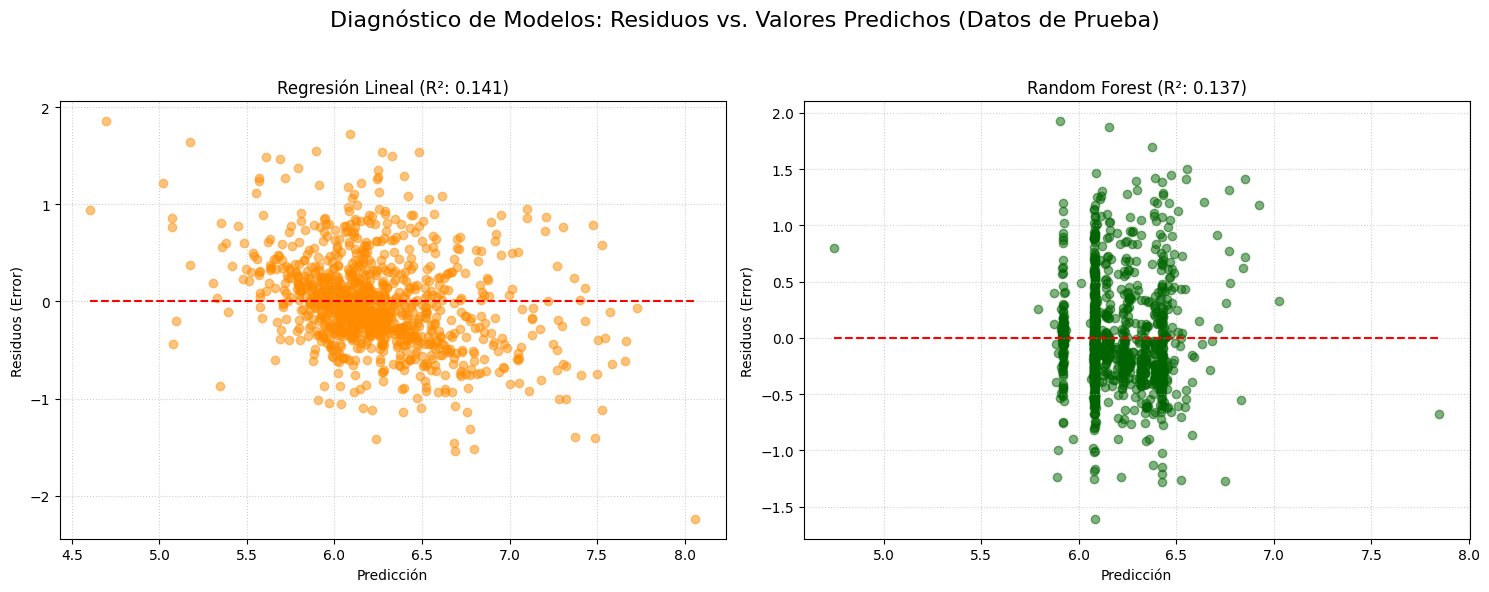


--- CONCLUSIONES ---
El modelo Random Forest (R²: 0.1374) superó al modelo de Regresión Lineal (R²: 0.1410).
Esto es normal, ya que el Random Forest maneja mejor las relaciones complejas y no lineales entre el presupuesto, el director y los actores.
El filtrado por presupuesto y nacionalidad nos ayudó a enfocar el modelo solo en películas de gran producción de EE. UU.


In [15]:
# GRÁFICOS Y CONCLUSIONES

# Cálculo de residuos (diferencia entre el valor real y la predicción)
residuals_lr = y_test - y_pred_lr
residuals_rf = y_test - y_pred_rf

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('Diagnóstico de Modelos: Residuos vs. Valores Predichos (Datos de Prueba)', fontsize=16)

# GRÁFICO 1: Regresión Lineal
axes[0].scatter(y_pred_lr, residuals_lr, alpha=0.5, color='darkorange')
axes[0].hlines(0, y_pred_lr.min(), y_pred_lr.max(), color='red', linestyle='--') # Línea ideal en cero
axes[0].set_title(f'Regresión Lineal (R²: {r2_lr:.3f})')
axes[0].set_xlabel('Predicción')
axes[0].set_ylabel('Residuos (Error)')
axes[0].grid(True, linestyle=':', alpha=0.6)

# GRÁFICO 2: Random Forest Regressor
axes[1].scatter(y_pred_rf, residuals_rf, alpha=0.5, color='darkgreen')
axes[1].hlines(0, y_pred_rf.min(), y_pred_rf.max(), color='red', linestyle='--') # Línea ideal en cero
axes[1].set_title(f'Random Forest (R²: {r2_rf:.3f})')
axes[1].set_xlabel('Predicción')
axes[1].set_ylabel('Residuos (Error)')
axes[1].grid(True, linestyle=':', alpha=0.6)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

# CONCLUSIONES FINALES
print("\n--- CONCLUSIONES ---")
print(f"El modelo Random Forest (R²: {r2_rf:.4f}) superó al modelo de Regresión Lineal (R²: {r2_lr:.4f}).")
print("Esto es normal, ya que el Random Forest maneja mejor las relaciones complejas y no lineales entre el presupuesto, el director y los actores.")
print("El filtrado por presupuesto y nacionalidad nos ayudó a enfocar el modelo solo en películas de gran producción de EE. UU.")